VERIFICACION DE EXISTENCIA DEL ESPEJISMO
alpha minimo requerido : 3.786617e-03 m^-1
alpha utilizado        : 5.000000e-03 m^-1
=> Condicion CUMPLIDA: el espejismo existe.

PARAMETROS UTILIZADOS
n0                 = 1,00030
alpha              = 5,000 x10^-3 m^-1
theta0             = -0,150 rad
y0                 = 3,00 m
x0                 = 0,00 m
xf                 = 60,0 m
Delta x (h)        = 5,00 x10^-3 m

RESULTADOS
x_retorno (simulado)  = 30,231 m
y_min (simulado)       = 0,7199 m
y_min (teorico)        = 0,7199 m
Error porcentual        = 0,000 %

Graficas guardadas: grafica_y_vs_x.png , grafica_theta_vs_x.png
Archivo resultados_rk4.npz guardado correctamente.


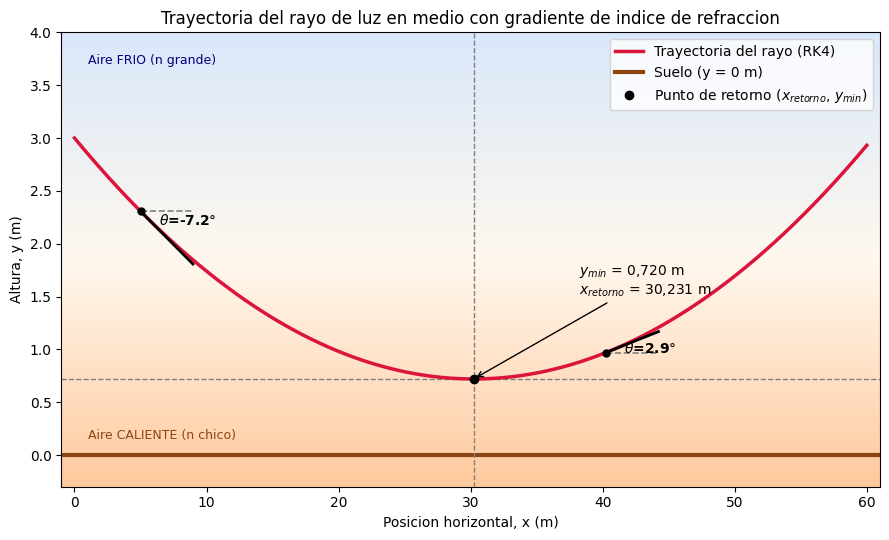

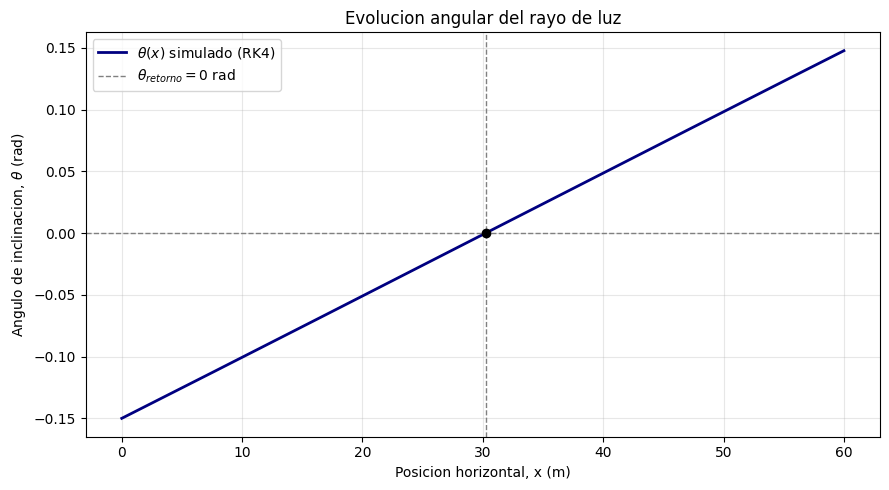

In [1]:
# ============================================================
#  DDD - PARTE 1: ESPEJISMOS Y REFRACCION DE LA LUZ
#  Metodo numerico: Runge-Kutta de 4to orden (RK4)
# ============================================================
#
# MODELO FISICO:
#   El rayo de luz se describe con un vector de estado u = (y, theta)
#   que evoluciona con la posicion horizontal x segun:
#
#       dy/dx     = tan(theta)                      ... (i)
#       dtheta/dx = (1/n(y)) * (dn/dy)               ... (ii)
#
#   con n(y) = n0 + alpha*y  (variacion lineal del indice de refraccion,
#   suelo caliente => alpha > 0)
#
#   El sistema se resuelve con RK4 porque es un metodo explicito de
#   4to orden que no requiere derivadas superiores: evalua la funcion
#   F(x,u) en 4 puntos (k1,k2,k3,k4) dentro de cada paso h y promedia
#   esas pendientes con pesos (1,2,2,1)/6.
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PARAMETROS DE LA SIMULACION
#    (todos dentro de los rangos exigidos en la guia, Seccion 3)
# ------------------------------------------------------------
n0     = 1.00030        # indice de refraccion en y = 0 m            [adim]
alpha  = 5.00e-3        # constante de variacion del indice           [m^-1]
theta0 = -0.150         # angulo inicial de disparo (hacia abajo)     [rad]
x0     = 0.00           # posicion horizontal inicial                 [m]
y0     = 3.00           # altura inicial del rayo                     [m]
xf     = 60.0           # posicion horizontal final de la simulacion  [m]
h      = 5.00e-3        # tamano de paso (delta x) del metodo RK4     [m]

# ------------------------------------------------------------
# 2. VERIFICACION DE LA EXISTENCIA DEL ESPEJISMO
#    Condicion teorica (deducida en la guia, pagina 3):
#        alpha > n0*(1-cos(theta0)) / (y0*cos(theta0))
#    Si no se cumple, el rayo nunca regresa: llega al suelo (y=0)
#    sin curvarse hacia arriba, y NO hay espejismo.
# ------------------------------------------------------------
alpha_minimo = n0 * (1 - np.cos(theta0)) / (y0 * np.cos(theta0))

print("=" * 60)
print("VERIFICACION DE EXISTENCIA DEL ESPEJISMO")
print("=" * 60)
print(f"alpha minimo requerido : {alpha_minimo:.6e} m^-1")
print(f"alpha utilizado        : {alpha:.6e} m^-1")
if alpha > alpha_minimo:
    print("=> Condicion CUMPLIDA: el espejismo existe.")
else:
    raise ValueError(
        "El valor de alpha elegido NO garantiza el espejismo. "
        "Aumente alpha o ajuste theta0 / y0."
    )

# ------------------------------------------------------------
# 3. FUNCIONES DEL MODELO FISICO
# ------------------------------------------------------------

def n_de_y(y):
    """
    Indice de refraccion del medio en funcion de la altura y.
    Modelo lineal: n(y) = n0 + alpha*y
    """
    return n0 + alpha * y


def dn_dy(y):
    """
    Derivada del indice de refraccion respecto a y.
    Como n(y) es lineal, dn/dy = alpha (constante para todo y).
    Se deja como funcion separada para que el codigo sea facil
    de adaptar si en el futuro se usa otro perfil n(y) no lineal.
    """
    return alpha


def F(x, u):
    """
    Lado derecho del sistema de EDOs (vector F(x,u) de la guia).

    Entrada:
        x : posicion horizontal actual (no se usa explicitamente porque
            el sistema es autonomo en x, pero se mantiene por generalidad
            del metodo RK4).
        u : vector de estado [y, theta]

    Salida:
        du/dx = [ dy/dx , dtheta/dx ] = [ tan(theta) , (1/n(y))*dn/dy ]
    """
    y, theta = u
    dydx = np.tan(theta)
    dthetadx = (1.0 / n_de_y(y)) * dn_dy(y)
    return np.array([dydx, dthetadx])


def paso_rk4(x, u, h):
    """
    Avanza UN paso del metodo de Runge-Kutta de 4to orden.

    Calcula 4 pendientes (k1..k4) evaluando F en distintos puntos
    del intervalo [x, x+h], las promedia con pesos (1,2,2,1)/6 y
    obtiene el siguiente vector de estado u_{i+1}.

    k1 : pendiente al inicio del intervalo
    k2 : pendiente en el punto medio, usando k1 para proyectar u
    k3 : pendiente en el punto medio, usando k2 para refinar u
    k4 : pendiente al final del intervalo, usando k3 para proyectar u
    """
    k1 = F(x, u)
    k2 = F(x + h / 2, u + (h / 2) * k1)
    k3 = F(x + h / 2, u + (h / 2) * k2)
    k4 = F(x + h, u + h * k3)

    u_siguiente = u + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return u_siguiente


# ------------------------------------------------------------
# 4. INTEGRACION NUMERICA: SE RECORRE TODO EL DOMINIO EN X
#    Se detiene si el rayo llega al suelo (y <= 0) por seguridad,
#    aunque ya garantizamos matematicamente que no deberia pasar.
# ------------------------------------------------------------

n_pasos = int(np.ceil((xf - x0) / h))

x_vals = np.zeros(n_pasos + 1)
y_vals = np.zeros(n_pasos + 1)
theta_vals = np.zeros(n_pasos + 1)

x_vals[0] = x0
y_vals[0] = y0
theta_vals[0] = theta0

u = np.array([y0, theta0])
x = x0
i_final = n_pasos  # indice real hasta donde se llena el arreglo

for i in range(n_pasos):
    u = paso_rk4(x, u, h)
    x = x + h

    x_vals[i + 1] = x
    y_vals[i + 1] = u[0]
    theta_vals[i + 1] = u[1]

    if u[0] <= 0:
        i_final = i + 1
        print("AVISO: el rayo llego al suelo antes de xf.")
        break

# Se recortan los arreglos hasta donde realmente se integro
x_vals = x_vals[: i_final + 1]
y_vals = y_vals[: i_final + 1]
theta_vals = theta_vals[: i_final + 1]

# ------------------------------------------------------------
# 5. DETECCION DEL PUNTO DE RETORNO (y_min SIMULADO)
#    El punto de retorno ocurre donde theta cruza por cero
#    (pasa de negativo, bajando, a positivo, subiendo).
#    Se usa interpolacion lineal entre los dos puntos que
#    rodean el cruce para obtener un valor mas preciso que
#    simplemente tomar el minimo del arreglo y_vals.
# ------------------------------------------------------------

def encontrar_punto_retorno(x_vals, y_vals, theta_vals):
    """
    Busca el indice donde theta cambia de signo (negativo -> positivo)
    e interpola linealmente para hallar x_retorno y y_min con mayor
    precision que la resolucion del paso h.
    """
    for k in range(len(theta_vals) - 1):
        if theta_vals[k] <= 0 and theta_vals[k + 1] > 0:
            # interpolacion lineal: fraccion del paso donde theta=0
            t1, t2 = theta_vals[k], theta_vals[k + 1]
            frac = -t1 / (t2 - t1)

            x_ret = x_vals[k] + frac * (x_vals[k + 1] - x_vals[k])
            y_ret = y_vals[k] + frac * (y_vals[k + 1] - y_vals[k])
            return x_ret, y_ret, k
    return None, None, None


x_retorno, y_min_sim, idx_retorno = encontrar_punto_retorno(
    x_vals, y_vals, theta_vals
)

if x_retorno is None:
    raise RuntimeError(
        "No se detecto punto de retorno dentro del dominio [x0, xf]. "
        "Aumente xf o revise los parametros."
    )

# ------------------------------------------------------------
# 6. VALOR TEORICO DE y_min Y PORCENTAJE DE ERROR
#    Formula (v) de la guia, deducida del invariante de Snell:
#        y_min = [ (n0 + alpha*y0)*cos(theta0) - n0 ] / alpha
# ------------------------------------------------------------

y_min_teo = ((n0 + alpha * y0) * np.cos(theta0) - n0) / alpha
error_porcentual = abs(y_min_sim - y_min_teo) / y_min_teo * 100

# ------------------------------------------------------------
# 7. REPORTE DE RESULTADOS EN CONSOLA
#    (se imprime con coma decimal, como exige el reporte)
# ------------------------------------------------------------

def fmt(valor, decimales=4):
    """Formatea un numero con coma decimal (formato del reporte)."""
    return f"{valor:.{decimales}f}".replace(".", ",")


print()
print("=" * 60)
print("PARAMETROS UTILIZADOS")
print("=" * 60)
print(f"n0                 = {fmt(n0,5)}")
print(f"alpha              = {fmt(alpha*1000,3)} x10^-3 m^-1")
print(f"theta0             = {fmt(theta0,3)} rad")
print(f"y0                 = {fmt(y0,2)} m")
print(f"x0                 = {fmt(x0,2)} m")
print(f"xf                 = {fmt(xf,1)} m")
print(f"Delta x (h)        = {fmt(h*1000,2)} x10^-3 m")

print()
print("=" * 60)
print("RESULTADOS")
print("=" * 60)
print(f"x_retorno (simulado)  = {fmt(x_retorno,3)} m")
print(f"y_min (simulado)       = {fmt(y_min_sim,4)} m")
print(f"y_min (teorico)        = {fmt(y_min_teo,4)} m")
print(f"Error porcentual        = {fmt(error_porcentual,3)} %")
print("=" * 60)

# ------------------------------------------------------------
# 8. GRAFICA y vs x (con fondo de gradiente termico + angulo local)
# ------------------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap

fig1, ax1 = plt.subplots(figsize=(9, 5.5))

y_min_plot = min(-0.3, y_vals.min() - 0.3)
y_max_plot = y0 + 1.0

# --- Fondo: representa el aire caliente (abajo) -> frio (arriba) ---
# Esto es solo VISUAL, ayuda a entender POR QUE se curva el rayo:
# cerca del suelo el aire esta caliente (n chico) y arriba esta frio (n grande).
cmap_aire = LinearSegmentedColormap.from_list(
    "aire", ["#ff9d4d", "#fff3e0", "#bcd4f7"]
)
gradiente = np.linspace(0, 1, 256).reshape(-1, 1)
ax1.imshow(gradiente, extent=[x_vals.min()-1, x_vals.max()+1, y_min_plot, y_max_plot],
        origin="lower", aspect="auto", cmap=cmap_aire, alpha=0.55, zorder=0)
ax1.text(1, 0.15, "Aire CALIENTE (n chico)", fontsize=9, color="saddlebrown")
ax1.text(1, y_max_plot-0.3, "Aire FRIO (n grande)", fontsize=9, color="navy")

# --- Trayectoria real ---
ax1.plot(x_vals, y_vals, color="crimson", linewidth=2.5, zorder=3,
        label="Trayectoria del rayo (RK4)")
ax1.axhline(0, color="saddlebrown", linewidth=3, zorder=2, label="Suelo (y = 0 m)")
ax1.axhline(y_min_sim, color="gray", linestyle="--", linewidth=1, zorder=2)
ax1.axvline(x_retorno, color="gray", linestyle="--", linewidth=1, zorder=2)
ax1.plot(x_retorno, y_min_sim, "o", color="black", zorder=5,
        label=r"Punto de retorno ($x_{retorno}$, $y_{min}$)")

# --- Indicadores de angulo local (linea horizontal de referencia + direccion real) ---
def dibujar_angulo(ax, x_arr, y_arr, theta_arr, x_objetivo, largo=4, color="black"):
    """
    Dibuja en el punto mas cercano a x_objetivo:
    - una linea horizontal punteada (referencia, angulo 0)
    - una linea solida en la direccion real del rayo (angulo theta)
    - la etiqueta theta=..° JUSTO en el hueco entre ambas lineas
    (sobre la bisectriz del angulo, cerca del vertice), para que
    quede claro que ese angulo es el que forman esas dos rectas.
    """
    idx = np.argmin(np.abs(x_arr - x_objetivo))
    xp, yp, th = x_arr[idx], y_arr[idx], theta_arr[idx]

    # las dos rectas que forman el angulo
    ax.plot([xp, xp+largo], [yp, yp], "--", color="gray", linewidth=1.2, zorder=4)
    ax.plot([xp, xp+largo*np.cos(th)], [yp, yp+largo*np.sin(th)],
            color=color, linewidth=2, zorder=5)
    ax.plot(xp, yp, "o", color=color, markersize=5, zorder=6)

    # etiqueta sobre la bisectriz (a mitad de camino entre las dos rectas)
    r_etiqueta = largo * 0.35
    angulo_bisectriz = th / 2
    x_txt = xp + r_etiqueta*np.cos(angulo_bisectriz)
    y_txt = yp + r_etiqueta*np.sin(angulo_bisectriz)
    ax.annotate(rf"$\theta$={np.degrees(th):.1f}$\degree$",
                xy=(x_txt, y_txt), fontsize=10, fontweight="bold",
                ha="left", va="center", zorder=7)

dibujar_angulo(ax1, x_vals, y_vals, theta_vals, x_objetivo=x_vals.min()+5)
dibujar_angulo(ax1, x_vals, y_vals, theta_vals, x_objetivo=x_retorno+10)

ax1.annotate(
    f"$y_{{min}}$ = {fmt(y_min_sim,3)} m\n$x_{{retorno}}$ = {fmt(x_retorno,3)} m",
    xy=(x_retorno, y_min_sim),
    xytext=(x_retorno + 8, y_min_sim + 0.8),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

ax1.set_title("Trayectoria del rayo de luz en medio con gradiente de "
            "indice de refraccion")
ax1.set_xlabel("Posicion horizontal, x (m)")
ax1.set_ylabel("Altura, y (m)")
ax1.legend(loc="upper right")
ax1.set_xlim(x_vals.min()-1, x_vals.max()+1)
ax1.set_ylim(y_min_plot, y_max_plot)

fig1.tight_layout()


fig1.savefig("grafica_y_vs_x.png", dpi=200)

# ------------------------------------------------------------
# 9. GRAFICA theta vs x
# ------------------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(9, 5))

ax2.plot(x_vals, theta_vals, color="navy", linewidth=2,
        label=r"$\theta(x)$ simulado (RK4)")
ax2.axhline(0, color="gray", linestyle="--", linewidth=1,
            label=r"$\theta_{retorno} = 0$ rad")
ax2.axvline(x_retorno, color="gray", linestyle="--", linewidth=1)
ax2.plot(x_retorno, 0, "o", color="black", zorder=5)

ax2.set_title("Evolucion angular del rayo de luz")
ax2.set_xlabel("Posicion horizontal, x (m)")
ax2.set_ylabel(r"Angulo de inclinacion, $\theta$ (rad)")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

fig2.tight_layout()
fig2.savefig("grafica_theta_vs_x.png", dpi=200)

print()
print("Graficas guardadas: grafica_y_vs_x.png , grafica_theta_vs_x.png")

# ------------------------------------------------------------
# 10. GUARDAR RESULTADOS PARA LA ANIMACION
# ------------------------------------------------------------

np.savez(
    "resultados_rk4.npz",
    x=x_vals,
    y=y_vals,
    theta=theta_vals,
    x_retorno=x_retorno,
    y_min_sim=y_min_sim,
    y_min_teo=y_min_teo,
    y0=y0
)

print("Archivo resultados_rk4.npz guardado correctamente.")